**Diana Itzel Soto Castañeda**

**Ciencia de Datos para Sensores Inteligentes**

## Imports

In [62]:
# system libraries
import os
import sys

print("Python:", sys.version)
print("Executable:", sys.executable)

Python: 3.9.13 (tags/v3.9.13:6de2ca5, May 17 2022, 16:36:42) [MSC v.1929 64 bit (AMD64)]
Executable: c:\Users\Diana\git\Course_CDSI_2026\practicas\PR1_Reconocimiento_Audio\.venv\Scripts\python.exe


Nota: Los entornos virtuales (.venv) no se encuentran en el repositorio de GitHub.

In [63]:
# data 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# audio
import IPython.display as ipd
from IPython.display import Audio, display, Markdown
import librosa
import librosa.display

# warnings (opional)
#import warnings
#if not sys.warnoptions:
#    warnings.simplefilter("ignore")
#warnings.filterwarnings("ignore", category=DeprecationWarning)

# Practica 1 — Reconocimiento de ADLs con audio


## Introducción

En esta práctica se aborda el reconocimiento de *Activities of Daily Living (ADLs)* utilizando señales de audio como fuente principal de información, el objetivo es el de identificar las siguientes actividades:
- Bajarle al WC (Bano)
- Lavar platos (Cocina)
- Conversación (Sala)
- Música de fondo (Oficina)
- Pasos al caminar (Múltiples lugares) [Pasos]
- Otros sonidos (Nula)

El desarrollo de la práctica sigue el siguiente flujo: Recolección y organización de datos, preprocesamiento de las señales de audio, extracción y selección de características relevantes, y finalmente la construcción y evaluación de modelos de clasificación

## Objetivo

El objetivo principal de esta práctica es aplicar técnicas de análisis de datos y aprendizaje automático para entrenar modelos capaces de reconocer automáticamente distintas actividades a partir de audio, así como evaluar su desempeño mediante métricas típicas.

## Desarrollo

Definición de etiquetas

In [64]:
## Definición de etiquetas válidas
Etiquetas_validas = {
    "BANO", "COCINA", "NULA",
    "OFICINA", "PASOS", "SALA"
}

### Recolección de audios y conformación del dataset

Los datos recolectados se encuentran en la carpeta Data de esta carpeta de proyecto. Los audios tiene una duración de 10 segundos y se recolectaron de manera colectiva.

### Procesamiento de los audios

In [65]:
#!pip install librosa

Carga de datos

In [66]:
Data = "data"
os.listdir(Data)

['Diana Itzel',
 'Ian Svén',
 'Javier R',
 'José Juárez',
 'Norman O',
 'Zarif León']

In [67]:
dirl_list = os.listdir(Data)
print(dirl_list)

for estudiante in dirl_list:
    path_estudiante = os.path.join(Data, estudiante)
    print(f"\n📁 {estudiante}")
    print(os.listdir(path_estudiante))

['Diana Itzel', 'Ian Svén', 'Javier R', 'José Juárez', 'Norman O', 'Zarif León']

📁 Diana Itzel
['DISC_BANO_01.wav', 'DISC_BANO_02.wav', 'DISC_BANO_03.wav', 'DISC_COCINA_01.wav', 'DISC_COCINA_02.wav', 'DISC_COCINA_03.wav', 'DISC_NULA_01.wav', 'DISC_NULA_02.wav', 'DISC_NULA_03.wav', 'DISC_OFICINA_01.wav', 'DISC_OFICINA_02.wav', 'DISC_OFICINA_03.wav', 'DISC_PASOS_01.wav', 'DISC_PASOS_02.wav', 'DISC_PASOS_03.wav', 'DISC_SALA_01.wav', 'DISC_SALA_02.wav', 'DISC_SALA_03.wav']

📁 Ian Svén
[]

📁 Javier R
['JR_bano_01.wav', 'JR_bano_02.wav', 'JR_bano_03.wav', 'JR_cocina_01.wav', 'JR_cocina_02.wav', 'JR_cocina_03.wav', 'JR_nula_01.wav', 'JR_nula_02.wav', 'JR_nula_03.wav', 'JR_oficina_01.wav', 'JR_oficina_02.wav', 'JR_oficina_03.wav', 'JR_pasos_01.wav', 'JR_pasos_02.wav', 'JR_pasos_03.wav', 'JR_sala_01.wav', 'JR_sala_02.wav', 'JR_sala_03.wav']

📁 José Juárez
['JFJA_BANO_01.wav', 'JFJA_BANO_02.wav', 'JFJA_BANO_03.wav', 'JFJA_COCINA_01.wav', 'JFJA_COCINA_02.wav', 'JFJA_COCINA_03.wav', 'JFJA_NULA_01

Dado que al iniciar la práctica se identificaron etiquetas discrepantes en los nombres de los archivos de audio, así como carpetas vacías correspondientes a algunos compañeros de clase, se decidió implementar mecanismos de validación y normalización durante la carga de los datos:

In [68]:
# Construcción del DataFrame
data = []

for estudiante in dirl_list:
    path_estudiante = os.path.join(Data, estudiante)

    if not os.path.isdir(path_estudiante):
        continue

    archivos = os.listdir(path_estudiante)
    if len(archivos) == 0:
        print(f"Carpeta vacía: {estudiante}")
        continue

    for archivo in archivos:
        if not archivo.lower().endswith(".wav"):
            continue

        # Extraer etiqueta del nombre del archivo
        nombre = archivo.replace(".wav", "")
        partes = nombre.split("_")

        if len(partes) < 2:
            print(f"Archivo ignorado (formato inválido): {archivo}")
            continue

        label = partes[1].upper()

        # Unificar NULO y NULA
        if label == "NULO":
            label = "NULA"

        if label not in Etiquetas_validas:
            print(f"Archivo ignorado (etiqueta inválida): {archivo}")
            continue

        path_archivo = os.path.join(path_estudiante, archivo)
        y, sr = librosa.load(path_archivo, sr=None)

        data.append({
            "estudiante": estudiante,
            "archivo": archivo,
            "etiqueta": label,
            "senal": y,
            "sr": sr
        })

CDSI2026_df = pd.DataFrame(data)
CDSI2026_df.etiqueta.value_counts()

Carpeta vacía: Ian Svén


etiqueta
BANO       15
COCINA     15
NULA       15
OFICINA    15
PASOS      15
SALA       15
Name: count, dtype: int64

Exploración de datos

Previo al preprocesamiento, se realizó una inspección exploratoria básica una señal de audio aleatoria mediante la reproducción y visualización de formas de onda y espectrogramas.

In [69]:
# Escucha de una muestra aleatoria
row = CDSI2026_df.sample(1, random_state=92).iloc[0]
print("Actividad:", row["etiqueta"])
display(Audio(row["senal"], rate=row["sr"]))

Actividad: SALA


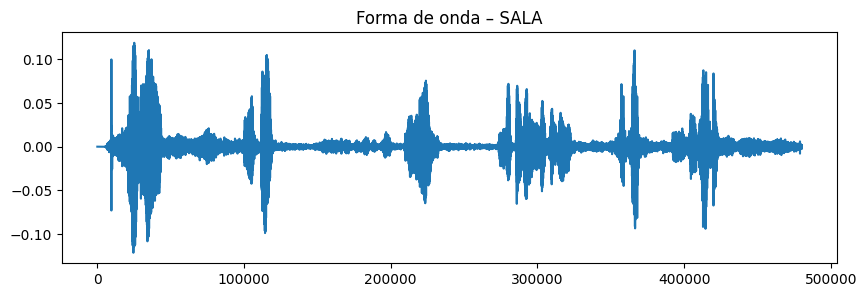

In [70]:
# Visualización de la forma de onda
plt.figure(figsize=(10,3))
plt.plot(row["senal"])
plt.title(f"Forma de onda – {row['etiqueta']}")
plt.show()


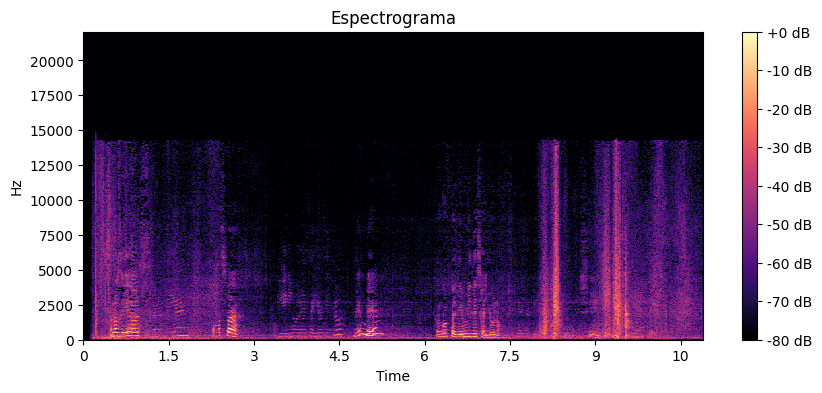

In [71]:
# Espectrograma
S = librosa.stft(row["senal"])
S_db = librosa.amplitude_to_db(abs(S), ref=np.max)

plt.figure(figsize=(10,4))
librosa.display.specshow(S_db, sr=row["sr"], x_axis="time", y_axis="hz")
plt.colorbar(format="%+2.0f dB")
plt.title("Espectrograma")
plt.show()


#### Aplicar una función para eliminar ruidos estacionarios de fondo

Aplicar la función eliminar_ruido_estacionario y generar una nueva columna con datos de la señal sin ruido

In [72]:
def aplicar_eliminacion_ruido(senal, sr, percentil_ruido=10):
    """Elimina ruido estacionario de una señal de audio"""
    S = librosa.stft(senal)
    magnitud, fase = librosa.magphase(S)
    perfil_ruido = np.percentile(magnitud, percentil_ruido, axis=1, keepdims=True)
    magnitud_limpia = np.maximum(magnitud - perfil_ruido, 0)
    S_limpia = magnitud_limpia * fase
    senal_sinruido = librosa.istft(S_limpia)
    return senal_sinruido

CDSI2026_df["senal_sin_ruido"] = CDSI2026_df.apply(
    lambda row: aplicar_eliminacion_ruido(row["senal"], row["sr"]),
    axis=1
)

Comparar Espectrogramas con y sin ruido de fondo

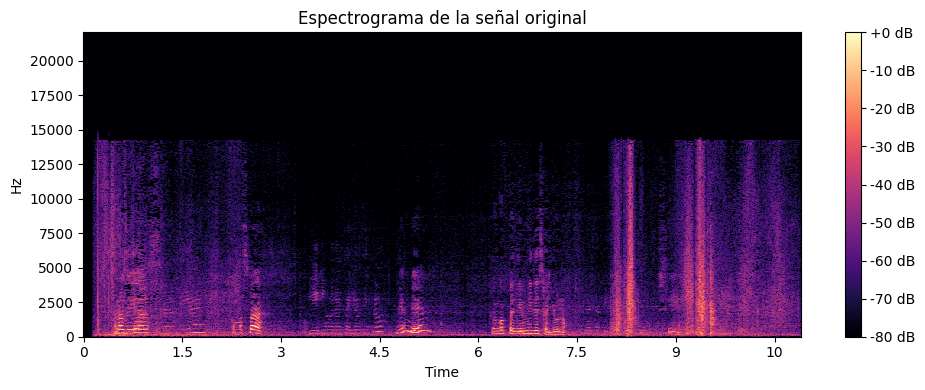

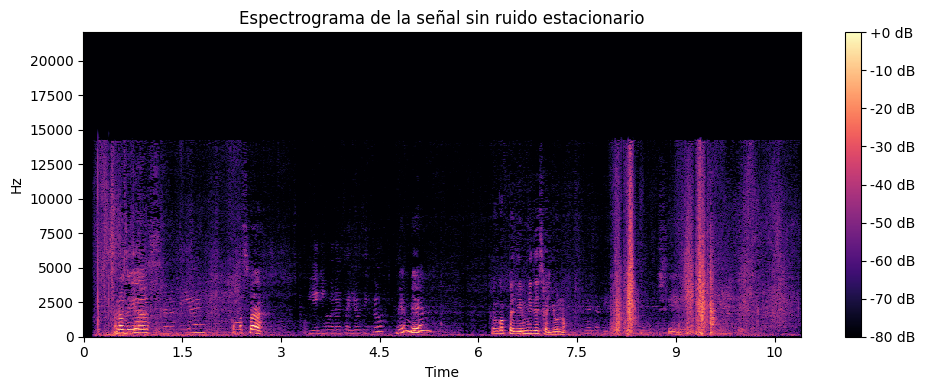

In [73]:
row = CDSI2026_df.sample(1, random_state=92).iloc[0]
# STFT - Señal original
S = librosa.stft(row["senal"])

# Convertir a decibeles
S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)

# Graficar espectrograma
plt.figure(figsize=(10,4))
librosa.display.specshow(
    S_db,
    sr=row["sr"],
    x_axis="time",
    y_axis="hz"
)
plt.colorbar(format="%+2.0f dB")
plt.title("Espectrograma de la señal original")
plt.tight_layout()
plt.show()

# STFT - Señal sin ruido
S = librosa.stft(row["senal_sin_ruido"])
S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)

plt.figure(figsize=(10,4))
librosa.display.specshow(
    S_db,
    sr=row["sr"],
    x_axis="time",
    y_axis="hz"
)
plt.colorbar(format="%+2.0f dB")
plt.title("Espectrograma de la señal sin ruido estacionario")
plt.tight_layout()
plt.show()

In [74]:
print("Original")
display(Audio(row["senal"], rate=row["sr"]))

print("Sin ruido estacionario")
display(Audio(row["senal_sin_ruido"], rate=row["sr"]))

Original


Sin ruido estacionario


Aunque la diferencia perceptual entre la señal original y la señal procesada es sutil, el análisis en el dominio de la frecuencia mediante espectrogramas permitió identificar, en algunos casos específicos, una reducción de componentes asociadas al ruido estacionario de fondo. 

#### Aplicar una función de normalización para asegurar un volumen constante y evitar sesgos

In [83]:
CDSI2026_df["senal_normalizada"] = CDSI2026_df["senal_sin_ruido"].apply(
    lambda s: librosa.util.normalize(s)
)

# Verificación de la normalización
row = CDSI2026_df.sample(1).iloc[0]

print("Máx normalizada:", np.max(np.abs(row["senal_normalizada"])))

Máx normalizada: 1.0


### Extracción y selección de características

#### MFCC

In [84]:
mfccs = []

for _, row in CDSI2026_df.iterrows():
    mfcc = librosa.feature.mfcc(
        y=row["senal_normalizada"],
        sr=row["sr"],
        n_mfcc=13
    )
    mfccs.append(np.mean(mfcc, axis=1))

mfcc_df = pd.DataFrame(
    mfccs,
    columns=[f"mfcc_{i+1}" for i in range(13)]
)


#### Zero Crossing Rate

In [77]:
zcr = []

for _, row in CDSI2026_df.iterrows():
    z = librosa.feature.zero_crossing_rate(row["senal_normalizada"])
    zcr.append(np.mean(z))

zcr_df = pd.DataFrame(zcr, columns=["zcr"])


#### Energía (RMS)

In [78]:
rms = []

for _, row in CDSI2026_df.iterrows():
    r = librosa.feature.rms(y=row["senal_normalizada"])
    rms.append(np.mean(r))

rms_df = pd.DataFrame(rms, columns=["rms"])


Ahora se vincula cada vector de las características extraidas con su respectiva etiqueta de actividad y se verifica la concatenación

In [79]:
X = pd.concat([mfcc_df, zcr_df, rms_df], axis=1)

y = CDSI2026_df["etiqueta"]

display(X.head()) ## head despliega sólo las primeras filas
display(y.head())

,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,zcr,rms
0,-227.945526,109.254883,-39.314205,-0.735043,-11.228836,27.293726,-6.795474,11.656944,7.840952,16.683451,-1.111534,4.151556,-5.844520,0.083297,0.060077
1,-210.259918,64.928917,-13.124597,32.933235,-0.399469,18.912355,-16.998960,10.134212,-14.861896,7.247721,-7.308037,4.009565,-3.795467,0.133384,0.070453
2,-262.514893,81.101189,-5.396962,25.025723,-5.228497,15.438561,-20.155287,9.749455,-6.270298,7.629604,-5.338158,1.288002,-7.674201,0.114772,0.044989
3,-269.289581,95.876587,-17.918037,31.598492,-7.222451,17.862984,-10.631896,20.848959,-8.691792,9.706056,-3.223147,11.347348,-8.622421,0.131182,0.036618
4,-349.234222,102.035255,-8.504502,16.836105,-6.263916,5.834454,-6.194636,4.633437,-4.256493,-1.288900,-3.306655,3.997533,-0.508150,0.083178,0.032184


0      BANO
1      BANO
2      BANO
3    COCINA
4    COCINA
Name: etiqueta, dtype: object

### Construcción y evaluación de modelos

Como parte de la práctica se construirán y evaluarán tres modelos de clasificación.

#### Separación de datos para **evaluación justa**

In [86]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3, #30% para test, 70% para train
    random_state=93, 
)

y_test.value_counts()

etiqueta
NULA       6
SALA       6
OFICINA    5
BANO       4
PASOS      3
COCINA     3
Name: count, dtype: int64

Al ver la distribución de los datos sin estratificación, decidí implementar una estratificación en búsqueda de mejorar la distribución:

In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3, #30% para test, 70% para train
    random_state=93,
    stratify=y # Mantener la proporción de clases en ambos conjuntos dado que el dataset es pequeño 
)

y_test.value_counts()

etiqueta
SALA       5
OFICINA    5
BANO       5
COCINA     4
NULA       4
PASOS      4
Name: count, dtype: int64

#### Escalado de características.

Si las características tienen escalas distintas pueden confundir al modelo, el escalado le da el mismo peso a todas las características.

In [88]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


#### SVM (Support Vector Machine)

Se evaluó un modelo de *Support Vector Machine* empleando diferentes *kernels*, con el fin de analizar el impacto de la función de decisión en el desempeño del clasificador.

- Kerel RBF

In [116]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    C=1,
    gamma="scale",
    random_state=92
)

svm_model.fit(X_train_scaled, y_train)
y_pred_rbf = svm_model.predict(X_test_scaled)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        BANO       0.60      0.60      0.60         5
      COCINA       0.60      0.75      0.67         4
        NULA       0.75      0.75      0.75         4
     OFICINA       0.75      0.60      0.67         5
       PASOS       0.75      0.75      0.75         4
        SALA       1.00      1.00      1.00         5

    accuracy                           0.74        27
   macro avg       0.74      0.74      0.74        27
weighted avg       0.75      0.74      0.74        27



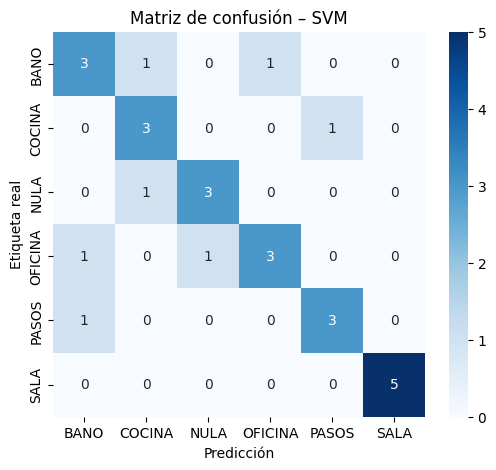

In [117]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rbf, labels=y.unique())

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=y.unique(),
    yticklabels=y.unique(),
    cmap="Blues"
)
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de confusión – SVM")
plt.show()

- Kernel lineal

In [118]:

svm_linear = SVC(kernel="linear", random_state=92)
svm_linear.fit(X_train_scaled, y_train)
y_pred_linear = svm_linear.predict(X_test_scaled)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_linear))


              precision    recall  f1-score   support

        BANO       0.75      0.60      0.67         5
      COCINA       1.00      0.75      0.86         4
        NULA       0.40      0.50      0.44         4
     OFICINA       0.44      0.80      0.57         5
       PASOS       1.00      0.25      0.40         4
        SALA       0.80      0.80      0.80         5

    accuracy                           0.63        27
   macro avg       0.73      0.62      0.62        27
weighted avg       0.72      0.63      0.63        27



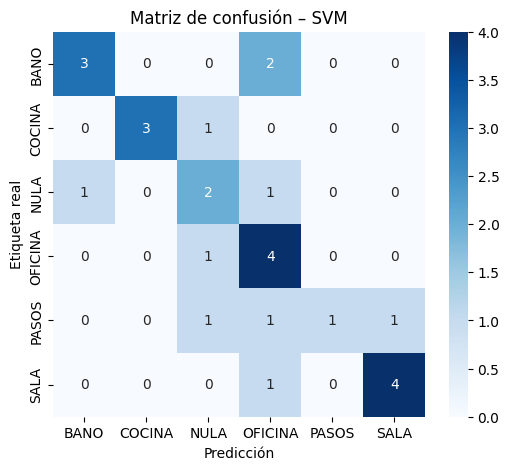

In [119]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_linear, labels=y.unique())

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=y.unique(),
    yticklabels=y.unique(),
    cmap="Blues"
)
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de confusión – SVM")
plt.show()

- Kernel polinomial

In [120]:
svm_poly = SVC(kernel="poly", degree=3, random_state=42)
svm_poly.fit(X_train_scaled, y_train)
y_pred_poly = svm_poly.predict(X_test_scaled)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_poly))


              precision    recall  f1-score   support

        BANO       0.67      0.40      0.50         5
      COCINA       0.50      0.25      0.33         4
        NULA       1.00      0.50      0.67         4
     OFICINA       1.00      0.20      0.33         5
       PASOS       0.25      1.00      0.40         4
        SALA       1.00      0.60      0.75         5

    accuracy                           0.48        27
   macro avg       0.74      0.49      0.50        27
weighted avg       0.75      0.48      0.50        27



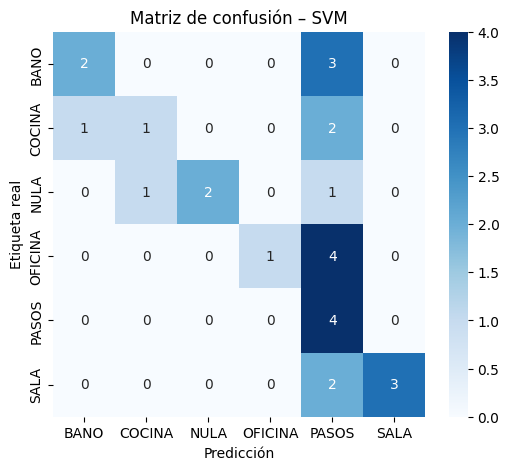

In [121]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_poly, labels=y.unique())

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=y.unique(),
    yticklabels=y.unique(),
    cmap="Blues"
)
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de confusión – SVM")
plt.show()

A partir de la comparación entre los distintos kernels evaluados, se observó que el kernel RBF presenta el mejor desempeño global, mostrando un equilibrio más adecuado entre precisión y recall en la mayoría de las clases.

#### Radom Forest

A continuación evaluaremos el desempeño de Random Forest bajo distintas configuraciones para comparar su estabilidad y desempeño general.

Variando el número de árboles

In [124]:
for n in [50, 100, 300]:
    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    print(f"\nRandom Forest - n_estimators={n}")
    print(classification_report(y_test, y_pred))



Random Forest - n_estimators=50
              precision    recall  f1-score   support

        BANO       0.71      1.00      0.83         5
      COCINA       0.67      1.00      0.80         4
        NULA       1.00      0.50      0.67         4
     OFICINA       0.75      0.60      0.67         5
       PASOS       1.00      0.50      0.67         4
        SALA       0.83      1.00      0.91         5

    accuracy                           0.78        27
   macro avg       0.83      0.77      0.76        27
weighted avg       0.82      0.78      0.76        27


Random Forest - n_estimators=100
              precision    recall  f1-score   support

        BANO       1.00      0.80      0.89         5
      COCINA       0.67      1.00      0.80         4
        NULA       0.50      0.50      0.50         4
     OFICINA       0.60      0.60      0.60         5
       PASOS       0.67      0.50      0.57         4
        SALA       0.80      0.80      0.80         5

    accura

Controlando profundidad

In [125]:
for depth in [None, 5, 10]:
    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=depth,
        random_state=42
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    print(f"\nRandom Forest - max_depth={depth}")
    print(classification_report(y_test, y_pred))



Random Forest - max_depth=None
              precision    recall  f1-score   support

        BANO       0.80      0.80      0.80         5
      COCINA       0.67      1.00      0.80         4
        NULA       1.00      0.50      0.67         4
     OFICINA       0.60      0.60      0.60         5
       PASOS       1.00      0.50      0.67         4
        SALA       0.71      1.00      0.83         5

    accuracy                           0.74        27
   macro avg       0.80      0.73      0.73        27
weighted avg       0.79      0.74      0.73        27


Random Forest - max_depth=5
              precision    recall  f1-score   support

        BANO       0.67      0.80      0.73         5
      COCINA       0.80      1.00      0.89         4
        NULA       0.67      0.50      0.57         4
     OFICINA       0.60      0.60      0.60         5
       PASOS       1.00      0.50      0.67         4
        SALA       0.83      1.00      0.91         5

    accuracy    

#### K-Nearest Neighbors (KNN)

In [127]:
from sklearn.neighbors import KNeighborsClassifier

knn_base = KNeighborsClassifier(
    n_neighbors=5
)

knn_base.fit(X_train_scaled, y_train)
y_pred_knn = knn_base.predict(X_test_scaled)

print("KNN - baseline (k=5)")
print(classification_report(y_test, y_pred_knn))


KNN - baseline (k=5)
              precision    recall  f1-score   support

        BANO       0.50      0.60      0.55         5
      COCINA       0.25      0.25      0.25         4
        NULA       0.50      0.25      0.33         4
     OFICINA       0.67      0.40      0.50         5
       PASOS       0.33      0.50      0.40         4
        SALA       0.83      1.00      0.91         5

    accuracy                           0.52        27
   macro avg       0.51      0.50      0.49        27
weighted avg       0.53      0.52      0.51        27



Variar el número de vecinos

In [128]:
for k in [1, 3, 5, 7, 9]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)

    print(f"\nKNN - n_neighbors={k}")
    print(classification_report(y_test, y_pred))


KNN - n_neighbors=1
              precision    recall  f1-score   support

        BANO       0.33      0.40      0.36         5
      COCINA       0.67      1.00      0.80         4
        NULA       1.00      0.25      0.40         4
     OFICINA       0.50      0.40      0.44         5
       PASOS       0.60      0.75      0.67         4
        SALA       0.80      0.80      0.80         5

    accuracy                           0.59        27
   macro avg       0.65      0.60      0.58        27
weighted avg       0.64      0.59      0.57        27


KNN - n_neighbors=3
              precision    recall  f1-score   support

        BANO       0.40      0.40      0.40         5
      COCINA       0.44      1.00      0.62         4
        NULA       0.33      0.25      0.29         4
     OFICINA       1.00      0.40      0.57         5
       PASOS       0.67      0.50      0.57         4
        SALA       1.00      1.00      1.00         5

    accuracy                       

Se evaluó un clasificador K-Nearest Neighbors variando el número de vecinos con el fin de analizar la sensibilidad del modelo a la elección del parámetro 𝑘. Dado que KNN se basa en distancias, las características fueron previamente escaladas. Los resultados muestran que valores intermedios de k ofrecen un mejor balance entre sobreajuste y generalización.